In [1]:
#@title Imports & Utils

import pandas as pd
import ast
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from sklearn import metrics

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, cross_val_predict
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import random
from IPython.display import clear_output

np.random.seed(123)
random.seed(123)

In [2]:
distmult_test_preds = pd.read_csv("/content/distmult-test-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)
distmult_val_preds = pd.read_csv("/content/distmult-val-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)

transformer_test_preds = pd.read_csv("/content/roberta-test-preds.tsv", index_col=False, sep="\t").applymap(lambda x: str(x).strip()).dropna().drop_duplicates().reset_index(drop=True)
transformer_val_preds = pd.read_csv("/content/roberta-val-preds.tsv", index_col=False, sep="\t").applymap(lambda x: str(x).strip()).dropna().drop_duplicates().reset_index(drop=True)

In [3]:
assert len(distmult_test_preds) == len(transformer_test_preds)
assert len(distmult_val_preds) == len(transformer_val_preds)

print(len(distmult_test_preds))
print(len(distmult_val_preds))

5103
5104


# **Data Exploration**

In [4]:
dictionary = {label: idx for idx, label in enumerate(set(distmult_test_preds['true'].values.tolist()))}
labels = list(dictionary.keys())
dictionary

{'Attack': 0, 'noRel': 1, 'Support': 2}

In [5]:
distmult_test_preds.head()

,true,predicted,sentence1,sentence2,Support_proba,Attack_proba,noRel_proba
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared...",0.713830,0.145418,0.140752
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h...",0.666950,0.130303,0.202747
2,Support,noRel,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...,0.171013,0.326373,0.502614
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin...",0.211178,0.296123,0.492699
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically,0.711803,0.126654,0.161543


In [6]:
transformer_test_preds.head()

,true,predicted,sentence1,sentence2,noRel_proba,Support_proba,Attack_proba
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared...",0.0742600858211517,0.91324782371521,0.012492056004703
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h...",0.3415154218673706,0.4565359055995941,0.2019486874341964
2,Support,Support,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...,0.0367063917219638,0.9572038054466248,0.0060897846706211
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin...",0.4822368919849396,0.2764529585838318,0.2413101643323898
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically,0.050105083733797,0.8530606627464294,0.0968342274427414


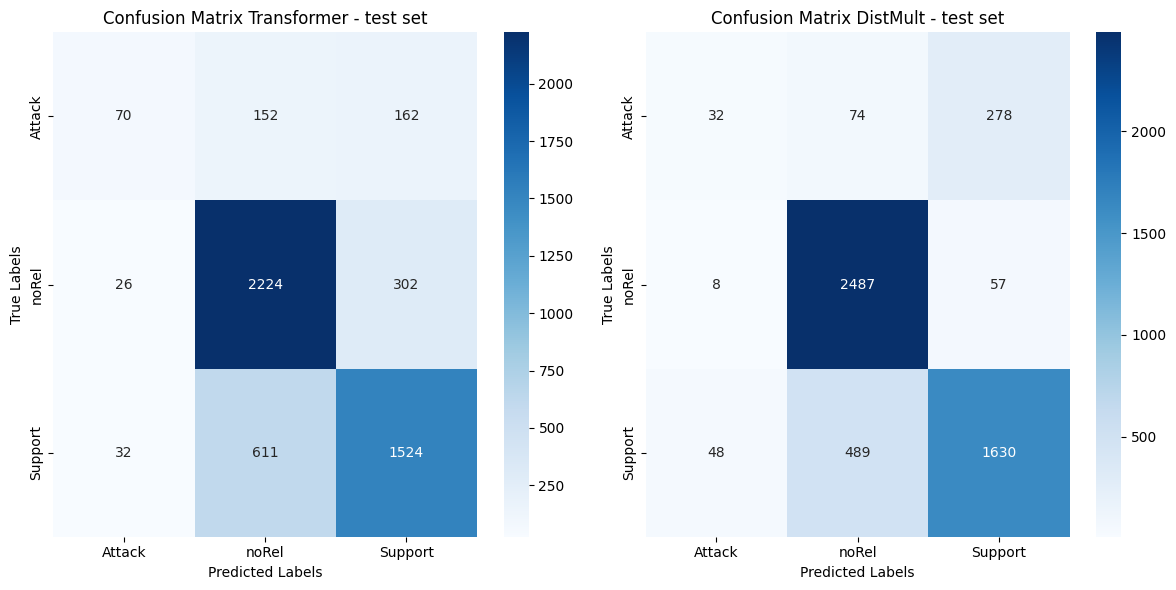

In [7]:
# Plotting Confusion Matrix for Transformer - test dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(transformer_test_preds['true'].map(lambda x: dictionary.get(x)), \
                             transformer_test_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Transformer - test set')

# Plotting Confusion Matrix for DistMult - test dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_test_preds['true'].map(lambda x: dictionary.get(x)), \
                             distmult_test_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - test set')

plt.tight_layout()
plt.show()

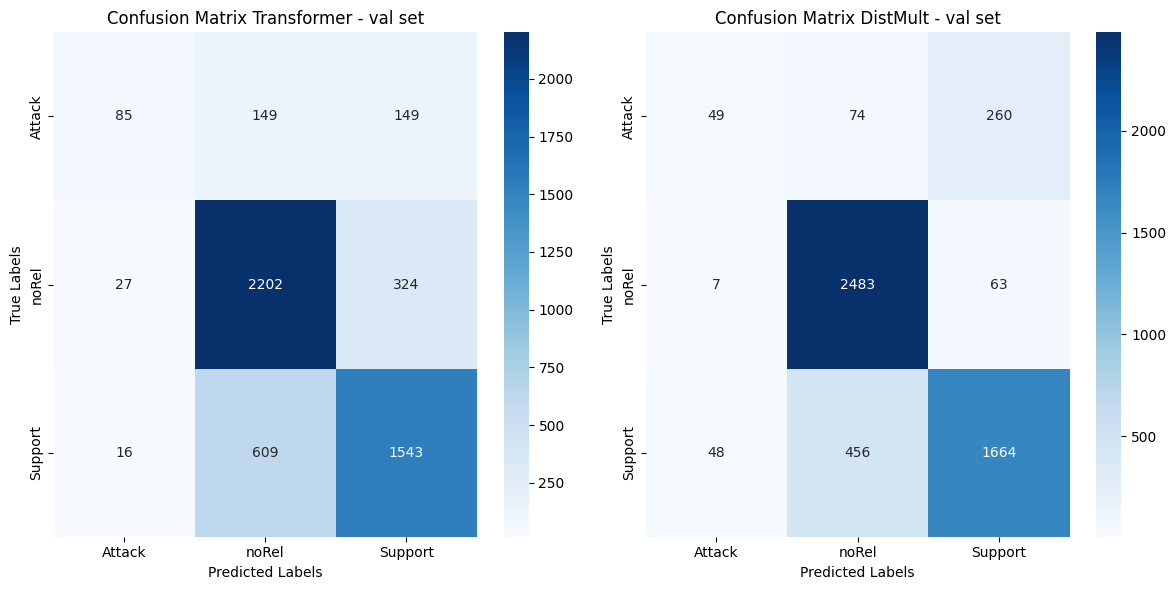

In [8]:
# Plotting Confusion Matrix for Transformer - val dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(transformer_val_preds['true'].map(lambda x: dictionary.get(x)), \
                             transformer_val_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Transformer - val set')

# Plotting Confusion Matrix for DistMult - val dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_val_preds['true'].map(lambda x: dictionary.get(x)), \
                             distmult_val_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - val set')

plt.tight_layout()
plt.show()

In [9]:
print("Transformer evaluation on test set: \n")
true = transformer_test_preds['true']
preds = transformer_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

Transformer evaluation on test set: 

F1-macro: 0.6033481818916039
F1-micro: 0.7481873407799333
Accuracy: 0.7481873407799333
Recall: 0.5856804799703671
Precision: 0.686011452180329


In [10]:
print("Transformer evaluation on val set: \n")
true = transformer_val_preds['true']
preds = transformer_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

Transformer evaluation on val set: 

F1-macro: 0.6230306089657685
F1-micro: 0.7503918495297806
Accuracy: 0.7503918495297806
Recall: 0.5987208902142744
Precision: 0.7244528010153011


In [11]:
print("DistMult evaluation on test set: \n")
true = distmult_test_preds['true']
preds = distmult_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

DistMult evaluation on test set: 

F1-macro: 0.6041515273039656
F1-micro: 0.8130511463844796
Accuracy: 0.8130511463844797
Recall: 0.603351694787893
Precision: 0.6695209130473804


In [12]:
print("DistMult evaluation on val set: \n")
true = distmult_val_preds['true']
preds = distmult_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

DistMult evaluation on val set: 

F1-macro: 0.6314657958009401
F1-micro: 0.822100313479624
Accuracy: 0.8221003134796239
Recall: 0.622682096340159
Precision: 0.7108976046438746


# **In-Pipeline evaluation**
Simulating what will happen if models are stacked in a pipeline:



### 1.
Distmults predics which nodes don't have any relation and the Transformer (trained with multi-class classification) predics the rest

In [13]:
no_rel_distmult = distmult_test_preds[distmult_test_preds['predicted'] == 'noRel']
len(no_rel_distmult)

3050

In [14]:
combined_dataset = pd.merge(distmult_test_preds, transformer_test_preds, on=['true', 'sentence1', 'sentence2'])
combined_dataset = combined_dataset.rename({'predicted_x': 'distmult_pred',\
                                            'predicted_y':'transformer_pred',\
                                            'true': 'y_true'}, axis=1)[['y_true', 'distmult_pred', 'transformer_pred']]
combined_dataset.head(2)

,y_true,distmult_pred,transformer_pred
0,Support,Support,Support
1,Support,Support,Support


In [15]:
combined_dataset['y_pred'] = np.where(combined_dataset['distmult_pred'] == 'noRel',
                                          combined_dataset['distmult_pred'],
                                          combined_dataset['transformer_pred'])
combined_dataset.head()

,y_true,distmult_pred,transformer_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,noRel,noRel
4,Attack,Support,Support,Support


In [16]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Transformer f1-score")
print(metrics.f1_score(transformer_test_preds['true'], transformer_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Transformer f1-score
0.6033481818916039
Combined f1-score
0.575696937978571


### 2.

The transformer predics which nodes don't have any relation and DistMult (trained with multi-class classification) predics the rest

In [17]:
combined_dataset = pd.merge(distmult_test_preds, transformer_test_preds, on=['true', 'sentence1', 'sentence2'])
combined_dataset = combined_dataset.rename({'predicted_x': 'distmult_pred',\
                                            'predicted_y':'transformer_pred',\
                                            'true': 'y_true'}, axis=1)[['y_true', 'distmult_pred', 'transformer_pred']]
combined_dataset['y_pred'] = np.where(combined_dataset['transformer_pred'] == 'noRel',
                                          combined_dataset['transformer_pred'],
                                          combined_dataset['distmult_pred'])
combined_dataset.head()

,y_true,distmult_pred,transformer_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,noRel,noRel
4,Attack,Support,Support,Support


In [18]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Transformer f1-score")
print(metrics.f1_score(transformer_test_preds['true'], transformer_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Transformer f1-score
0.6033481818916039
Combined f1-score
0.5174173516789876


# **Meta-Classifier**

In [91]:
dictionary = {label: idx for idx, label in enumerate(set(distmult_test_preds['true'].values.tolist()))}
dictionary

{'Attack': 0, 'noRel': 1, 'Support': 2}

In [92]:
combined_transformer_preds = pd.concat([transformer_test_preds, transformer_val_preds], axis=0)
combined_distmult_preds = pd.concat([distmult_test_preds, distmult_val_preds], axis=0)

assert len(combined_distmult_preds) == len(combined_transformer_preds)

### Using only predictions from the two models

In [93]:
combined_dataset_meta_learner = pd.merge(combined_distmult_preds, combined_transformer_preds, on=['true', 'sentence1', 'sentence2'])[['predicted_x', 'predicted_y', 'true']]
combined_dataset_meta_learner = combined_dataset_meta_learner.rename({'predicted_x': 'distmult_pred', 'predicted_y':'transformer_pred'}, axis=1)

combined_dataset_meta_learner = combined_dataset_meta_learner.applymap(lambda x: dictionary.get(x))

true = combined_dataset_meta_learner.pop('true')

In [94]:
combined_dataset_meta_learner.dropna().drop_duplicates().reset_index(drop=True)
combined_dataset_meta_learner.head(5)

,distmult_pred,transformer_pred
0,2,2
1,2,2
2,1,2
3,1,1
4,2,2


#### Decision Trees & Random Forests

In [95]:
X = combined_dataset_meta_learner
y = true
scoring = ['f1_macro', 'f1_micro', 'accuracy', 'precision_macro', 'recall_macro']

In [96]:
clf = DecisionTreeClassifier(random_state=123)
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6804183628351634
F1-micro: 0.8352786824735106
Accuracy: 0.8352786824735106
Precision-macro: 0.7850573773105296
Recall-macro: 0.6616790000224425


In [97]:
clf = RandomForestClassifier(max_depth=12, random_state=123)
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6804183628351634
F1-micro: 0.8352786824735106
Accuracy: 0.8352786824735106
Precision-macro: 0.7850573773105296
Recall-macro: 0.6616790000224425


In [98]:
y_pred = cross_val_predict(clf, X, y, cv=5)
best_results = pd.DataFrame({'distmult_pred': X['distmult_pred'], 'transformer_pred': X['transformer_pred'], 'rfc_pred': y_pred , 'true': y})
best_results.to_csv('best_results_meta_learner.csv', index=False)

#### Support Vector Classifiers

In [ ]:
clf = SVC(kernel='rbf', gamma='scale', random_state=123, class_weight='balanced')
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6534372096427776
F1-micro: 0.7577625607955533
Accuracy: 0.7577625607955533
Precision-macro: 0.6502060651696258
Recall-macro: 0.6997896070404571


#### Ada Boost Classifier

In [ ]:
clf = AdaBoostClassifier(n_estimators=100, random_state=123)
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6716978471001428
F1-micro: 0.8301734844537085
Accuracy: 0.8301734844537085
Precision-macro: 0.7849340438965318
Recall-macro: 0.6526781725506161


#### Gaussian Naive Bayes

In [ ]:
clf = GaussianNB()
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.5683641855067606
F1-micro: 0.8227759683863123
Accuracy: 0.8227759683863123
Precision-macro: 0.5526965898135618
Recall-macro: 0.5922240889056757


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning

#### K-Neighbors Classifier

In [ ]:
clf = KNeighborsClassifier(n_neighbors=5)
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6426272053873938
F1-micro: 0.7956956748306409
Accuracy: 0.7956956748306409
Precision-macro: 0.7511493976866686
Recall-macro: 0.6432451595780686


#### MLP

In [ ]:
clf = MLPClassifier(random_state=123, max_iter=300)
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6774271209680284
F1-micro: 0.8321536824735105
Accuracy: 0.8321536824735105
Precision-macro: 0.7832612520476852
Recall-macro: 0.6580948270319091


#### Gradient Boosting Machines

In [ ]:
clf = GradientBoostingClassifier()
scores = cross_validate(clf, X, y, scoring=scoring, cv=5)

print(f"F1-macro: {scores['test_f1_macro'].mean()}")
print(f"F1-micro: {scores['test_f1_micro'].mean()}")
print(f"Accuracy: {scores['test_accuracy'].mean()}")
print(f"Precision-macro: {scores['test_precision_macro'].mean()}")
print(f"Recall-macro: {scores['test_recall_macro'].mean()}")

F1-macro: 0.6804183628351634
F1-micro: 0.8352786824735106
Accuracy: 0.8352786824735106
Precision-macro: 0.7850573773105296
Recall-macro: 0.6616790000224425


#### Hypertuning

In [139]:
X_train, X_test, y_train, y_test = train_test_split(combined_dataset_meta_learner, true, test_size=0.2, random_state=123)

##### Random Forests

In [140]:
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'criterion': ['gini', 'entropy'],  # Function to measure the quality of a split
    'max_depth': [None, 5, 10, 20],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'random_state': [123],  # Random seed for reproducibility
}

rf_classifier = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='f1_macro')

grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Predict on test data using the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

Best parameters found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'random_state': 123}
Test F1-macro of the best model: 0.6832517324823457


##### Gaussian Naive Bayes

In [ ]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],  # Portion of the largest variance of all features that is added to variances for calculation stability
}

grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Predict on test data using the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

Best parameters found: {'var_smoothing': 1e-09}
Test F1-macro of the best model: 0.5737028375721602


##### Gradient Boosting Classifier

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.5],  # Step size shrinkage used in update to prevent overfitting
    'n_estimators': [50, 100, 200],  # Number of boosting stages to be run
    'max_depth': [3, 5, 7],  # Maximum depth of the individual estimators
    'min_samples_split': [2, 5, 10],  # The minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # The minimum number of samples required to be at a leaf node
    'random_state': [123],  # Random seed for reproducibility
}

grid_search = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid=param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Predict on test data using the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

Best parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'random_state': 123}
Test F1-macro of the best model: 0.6832517324823457


##### Ada Boost

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],  # Number of boosting stages to be run
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],  # Weight learning rate (shrinks the contribution of each classifier)
    'algorithm': ['SAMME', 'SAMME.R'],  # Algorithm used for weight updating
    'random_state': [123],  # Random seed for reproducibility
}

grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Predict on test data using the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

Best parameters found: {'algorithm': 'SAMME.R', 'learning_rate': 0.5, 'n_estimators': 300, 'random_state': 123}
Test F1-macro of the best model: 0.6832517324823457


### Using also the text

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available else torch.device('cpu')

print(device)
dictionary

cuda


{'noRel': 0, 'Attack': 1, 'Support': 2}

In [ ]:
class CNN_Text(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super(CNN_Text, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv2d(1, 100, (3, embedding_dim))
        self.fc1 = nn.Linear(100 + 2, 50)  # 100 for text output + 2 for numerical features
        self.fc2 = nn.Linear(50, num_classes)

    def forward(self, x_text, x_num1, x_num2):
        x_text = self.embedding(x_text)
        x_text = x_text.unsqueeze(1)
        x_text = F.relu(self.conv1(x_text)).squeeze(3)
        x_text = F.max_pool1d(x_text, x_text.size(2)).squeeze(2)

        # Concatenate text output with numerical features
        x = torch.cat((x_text, x_num1.unsqueeze(1), x_num2.unsqueeze(1)), dim=1)
        x = self.fc1(x)
        x = self.fc2(F.relu(x))
        return x

In [ ]:
class CNN_Dataset(Dataset):
    def __init__(self, X_num1, X_num2, X_text, y):
        self.X_num1 = torch.tensor(X_num1, dtype=torch.float32)
        self.X_num2 = torch.tensor(X_num2, dtype=torch.float32)
        self.X_text = torch.tensor(X_text, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num1[idx].to(device),\
                self.X_num2[idx].to(device),\
                self.X_text[idx].to(device),\
                self.y[idx].to(device)

In [ ]:
combined_dataset = pd.DataFrame({'y_true': combined_distmult_preds['true'].map(lambda x: dictionary.get(x)),
                                 'distmult_pred': combined_distmult_preds['predicted'].map(lambda x: dictionary.get(x)),
                                 'transformer_pred': combined_transformer_preds['predicted'].map(lambda x: dictionary.get(x)),
                                 'text': combined_distmult_preds['sentence1'] + ' ' + combined_distmult_preds['sentence2']})

X_num1 = combined_dataset['distmult_pred'].values
X_num2 = combined_dataset['transformer_pred'].values

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(combined_dataset['text']).toarray()

y = combined_dataset['y_true'].values

# Split data into train and test sets
X_num1_train, X_num1_test, X_num2_train, X_num2_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_num1, X_num2, X_text, y, test_size=0.2, random_state=42)

# Define hyperparameters
vocab_size = len(vectorizer.vocabulary_)
embedding_dim = 100
num_classes = 3
lr = 0.001
batch_size = 32
num_epochs = 50

# Create datasets and dataloaders
train_dataset = CNN_Dataset(X_num1_train, X_num2_train, X_text_train, y_train)
test_dataset = CNN_Dataset(X_num1_test, X_num2_test, X_text_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model, optimizer, and loss function
model = CNN_Text(vocab_size, embedding_dim, num_classes)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

best_loss = float("inf")
best_model_path = 'best_model.pth'

# Training loop
for epoch in range(num_epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    avg_loss = 0
    for batch in loop:
        optimizer.zero_grad()
        X_num1_batch, X_num2_batch, X_text_batch, y_batch = batch
        outputs = model(X_text_batch, X_num1_batch, X_num2_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch+1}/{num_epochs}")
        loop.set_postfix(loss=loss.item())
        avg_loss += loss.item()

    avg_loss = avg_loss/len(train_loader)
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# Evaluation
print(f"Best Loss: {best_loss}")
# Load the best model for prediction
best_model = CNN_Text(vocab_size, embedding_dim, num_classes)
best_model.load_state_dict(torch.load(best_model_path))
best_model.to(device)
best_model.eval()

y_true = []
y_pred = []
with torch.no_grad():
    for batch in test_loader:
        X_num1_batch, X_num2_batch, X_text_batch, y_batch = batch
        outputs = best_model(X_text_batch, X_num1_batch, X_num2_batch)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

Epoch 1/50: 100%|██████████| 256/256 [00:13<00:00, 18.92it/s, loss=0.343]


Epoch 1/50, Loss: 0.7613


Epoch 2/50: 100%|██████████| 256/256 [00:11<00:00, 21.84it/s, loss=0.253]


Epoch 2/50, Loss: 0.5231


Epoch 3/50: 100%|██████████| 256/256 [00:12<00:00, 21.32it/s, loss=0.492]


...

Epoch 48/50, Loss: 0.4319


Epoch 49/50: 100%|██████████| 256/256 [00:13<00:00, 19.67it/s, loss=0.284]


Epoch 49/50, Loss: 0.4313


Epoch 50/50: 100%|██████████| 256/256 [00:13<00:00, 19.59it/s, loss=0.101]


Epoch 50/50, Loss: 0.4292
Best Loss: 0.42924384245998226


In [ ]:
# Calculate F1 score, precision, and recall
f1 = metrics.f1_score(y_true, y_pred, average='macro')
precision = metrics.precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = metrics.recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Macro F1 Score: {f1:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

Macro F1 Score: 0.6394
Macro Precision: 0.7219
Macro Recall: 0.6325


# Averaging Models

In [ ]:
transformer_f1 = metrics.f1_score(transformer_test_preds['true'], transformer_test_preds['predicted'], average='macro')
distmult_f1 = metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro')

print(transformer_f1, distmult_f1)

0.6033481818916039 0.6041515273039656


In [ ]:
weight_transformer = transformer_f1 / (transformer_f1 + distmult_f1)
weight_distmult = distmult_f1 / (transformer_f1 + distmult_f1)

print(weight_transformer, weight_distmult)

0.49966735171601123 0.5003326482839888


In [ ]:
combined_data = pd.DataFrame({
    'true' : transformer_test_preds['true'],
    'transformer_support_proba': transformer_test_preds['Support_proba'].map(lambda x: float(x) * weight_transformer),
    'distmult_support_proba': distmult_test_preds['Support_proba'].map(lambda x: float(x) * weight_distmult),
    'transformer_attack_proba': transformer_test_preds['Attack_proba'].map(lambda x: float(x) * weight_transformer),
    'distmult_attack_proba': distmult_test_preds['Attack_proba'].map(lambda x: float(x) * weight_distmult),
    'transformer_noRel_proba': transformer_test_preds['noRel_proba'].map(lambda x: float(x) * weight_transformer),
    'distmult_noRel_proba': distmult_test_preds['noRel_proba'].map(lambda x: float(x) * weight_distmult)
})

In [ ]:
combined_data['Support_proba'] =  combined_data['transformer_support_proba'] + combined_data['distmult_support_proba']
combined_data['Attack_proba'] =  combined_data['transformer_attack_proba'] + combined_data['distmult_attack_proba']
combined_data['noRel_proba'] =  combined_data['transformer_noRel_proba'] + combined_data['distmult_noRel_proba']

In [ ]:
probabilities = combined_data[['Support_proba', 'Attack_proba', 'noRel_proba']].values.tolist()
dictionary = {0: "Support", 1: "Attack", 2: "noRel"}

In [ ]:
combined_data['predicted'] = [dictionary.get(np.argmax(row)) for row in probabilities]

In [ ]:
# Calculate F1 score, precision, and recall
f1 = metrics.f1_score(combined_data['true'], combined_data['predicted'], average='macro')
precision = metrics.precision_score(combined_data['true'], combined_data['predicted'], average='macro', zero_division=0)
recall = metrics.recall_score(combined_data['true'], combined_data['predicted'], average='macro', zero_division=0)

print(f"Macro F1 Score: {f1:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

Macro F1 Score: 0.6495
Macro Precision: 0.7789
Macro Recall: 0.6350


# Accuracy analysis

In [120]:
dictionary
dictionary_reverse = {v: k for k, v in dictionary.items()} #inverted
dictionary_reverse

{0: 'Attack', 1: 'noRel', 2: 'Support'}

In [121]:
best_results.replace(dictionary_reverse, inplace=True)

In [122]:
best_results.head(5)

,distmult_pred,transformer_pred,rfc_pred,true
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,noRel,Support,Support,Support
3,noRel,noRel,noRel,Attack
4,Support,Support,Support,Attack


In [123]:
count_same_values = (best_results['distmult_pred'] == best_results['transformer_pred']).sum()
print(f"Distmult and transformer agree: {round(count_same_values/len(best_results)*100, 3)}%")

Distmult and transformer agree: 70.744%


In [124]:
count_same_values = ((best_results['distmult_pred'] == best_results['transformer_pred']) &
                     (best_results['transformer_pred'] == best_results['rfc_pred'])).sum()
print(f"All models agree: {round(count_same_values/len(best_results)*100, 3)}%")

All models agree: 70.744%


In [125]:
count_same_values = ((best_results['distmult_pred'] == best_results['transformer_pred']) & \
                     (best_results['transformer_pred'] == best_results['true'])).sum()
print(f"Distmult and roberta agree and result is true: {round(count_same_values/len(best_results)*100, 3)}%")

Distmult and roberta agree and result is true: 65.305%


In [126]:
count_same_values = ((best_results['distmult_pred'] == best_results['transformer_pred']) & \
                     (best_results['distmult_pred'] == best_results['true']) & \
                     (best_results['transformer_pred'] == best_results['rfc_pred'])).sum()
print(f"All models agree and result is true: {round(count_same_values/len(best_results)*100, 3)}%")

All models agree and result is true: 65.305%


In [127]:
count_same_values = ((best_results['transformer_pred'] != best_results['rfc_pred'])).sum()
print(f"RFC disagree from transformer: {round(count_same_values/len(best_results)*100, 3)}%")

RFC disagree from transformer: 13.742%


In [128]:
count_same_values = ((best_results['distmult_pred'] != best_results['rfc_pred'])).sum()
print(f"RFC disagree from distmult: {round(count_same_values/len(best_results)*100, 3)}%")

RFC disagree from distmult: 15.514%


In [129]:
count_same_values = ((best_results['distmult_pred'] != best_results['rfc_pred']) & \
                     (best_results['transformer_pred'] != best_results['rfc_pred'])).sum()
print(f"RFC disagree from distmult and transformer: {round(count_same_values/len(best_results)*100, 3)}%")

RFC disagree from distmult and transformer: 0.0%


In [130]:
count_same_values = ((best_results['transformer_pred'] != best_results['rfc_pred']) & \
                     (best_results['rfc_pred'] == best_results['true'])).sum()
print(f"RFC disagree from transformer and result is true: {round(count_same_values/len(best_results)*100, 3)}%")

RFC disagree from transformer and result is true: 9.971%


In [131]:
count_same_values = ((best_results['distmult_pred'] != best_results['rfc_pred']) & \
                     (best_results['rfc_pred'] == best_results['true'])).sum()
print(f"RFC disagree from distmult and result is true: {round(count_same_values/len(best_results)*100, 3)}%")

RFC disagree from distmult and result is true: 8.252%


In [132]:
count_same_values = ((best_results['rfc_pred'] == best_results['true'])).sum()
print(f"RFC is true: {round(count_same_values/len(best_results)*100, 3)}%")

RFC is true: 83.528%


In [133]:
count_same_values = ((best_results['distmult_pred'] == best_results['true'])).sum()
print(f"DistMult is true: {round(count_same_values/len(best_results)*100, 3)}%")

DistMult is true: 81.944%


In [134]:
count_same_values = ((best_results['transformer_pred'] == best_results['true'])).sum()
print(f"Transformer is true: {round(count_same_values/len(best_results)*100, 3)}%")

Transformer is true: 75.036%


In [135]:
best_results['distmult_pred'].value_counts() / len(best_results)

distmult_pred
noRel      0.593770
Support    0.387372
Attack     0.018858
Name: count, dtype: float64

In [136]:
best_results['transformer_pred'].value_counts() / len(best_results)

transformer_pred
noRel      0.580121
Support    0.394978
Attack     0.024901
Name: count, dtype: float64

In [137]:
best_results['rfc_pred'].value_counts() / len(best_results)

rfc_pred
Support    0.515212
noRel      0.461867
Attack     0.022921
Name: count, dtype: float64

In [138]:
best_results['true'].value_counts() / len(best_results)

true
noRel      0.500313
Support    0.427277
Attack     0.072411
Name: count, dtype: float64

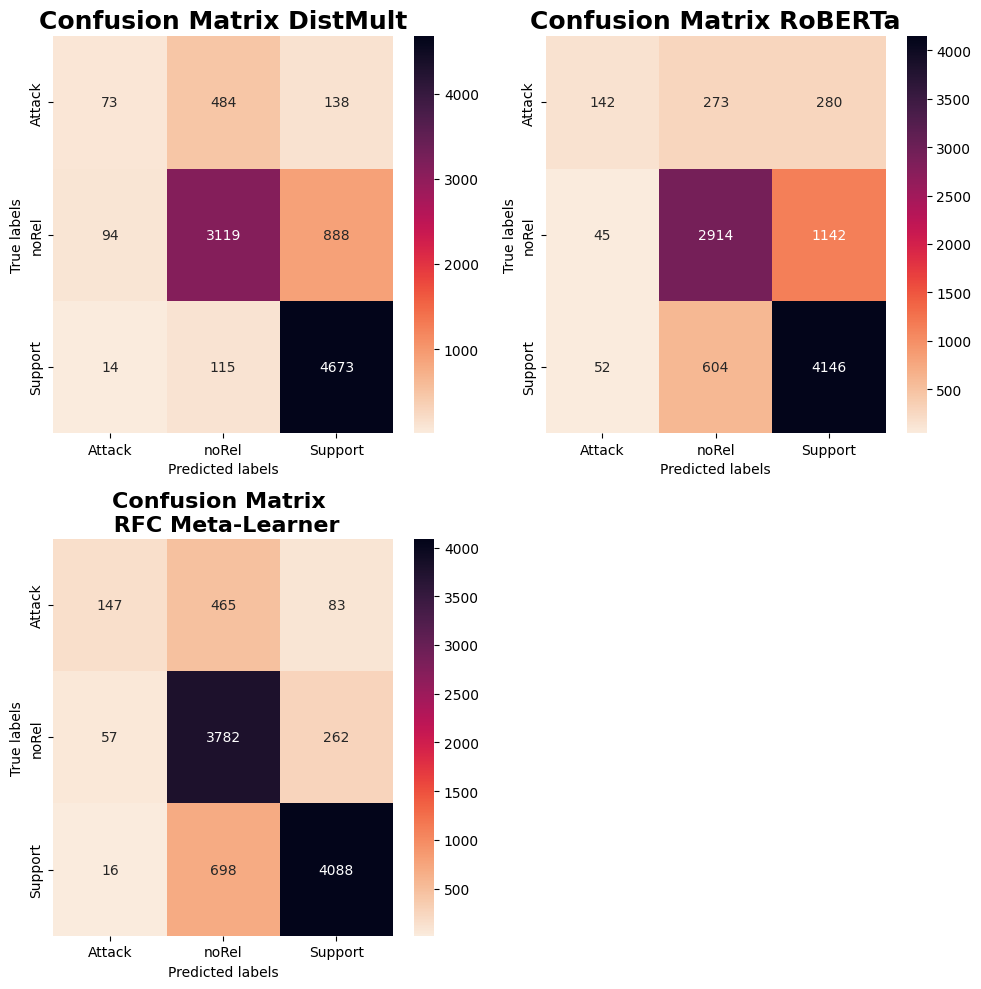

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cms = [
    confusion_matrix(best_results['true'], best_results['distmult_pred']),
    confusion_matrix(best_results['true'], best_results['transformer_pred']),
    confusion_matrix(best_results['true'], best_results['rfc_pred'])
]
titles = ['Confusion Matrix DistMult',
          'Confusion Matrix RoBERTa',
          'Confusion Matrix \n RFC Meta-Learner']

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (cm, title) in enumerate(zip(cms[:2], titles[:2])):
    sns.heatmap(cm, annot=True, cmap=sns.cm.rocket_r, fmt='g', ax=axes[0, i], xticklabels=list(dictionary.keys()), yticklabels=list(dictionary.keys()))
    axes[0, i].set_xlabel('Predicted labels')
    axes[0, i].set_ylabel('True labels')
    axes[0, i].set_title(title, weight='bold', fontdict={'fontsize':18})

sns.heatmap(cms[2], annot=True, cmap=sns.cm.rocket_r, fmt='g', ax=axes[1, 0], xticklabels=list(dictionary.keys()), yticklabels=list(dictionary.keys()))
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')
axes[1, 0].set_title(titles[2], weight='bold', fontdict={'fontsize':16})

# Hide the empty subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('confusion-matrix.pdf', dpi=1200)